# IMPORT LIBRARIES

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
import matplotlib.pyplot as plt

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
train_datagen = ImageDataGenerator(
    rescale = .1/255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True,
    shear_range = 0.2
)
val_datagen = ImageDataGenerator(rescale = .1/255)
test_datagen = ImageDataGenerator(rescale = .1/255)

In [3]:
train_data = train_datagen.flow_from_directory(
    'Train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical'
)

Found 1322 images belonging to 3 classes.


In [4]:
val_data = val_datagen.flow_from_directory(
    'Validation',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical'
)

Found 60 images belonging to 3 classes.


In [5]:
test_data = test_datagen.flow_from_directory(
    'Test',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = False
)

Found 150 images belonging to 3 classes.


# CNN

In [6]:
model = Sequential([
    Conv2D(32, (3,3),
           activation = 'relu',
           input_shape = (224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(3, activation = 'softmax'),
])

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,395,395 (73.99 MB)

 Trainable params: 19,395,395 (73.99 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data
)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.4251 - loss: 1.0459 - val_accuracy: 0.4667 - val_loss: 0.9740
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 361s 9s/step - accuracy: 0.6097 - loss: 0.7688 - val_accuracy: 0.6500 - val_loss: 0.6637
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 348s 8s/step - accuracy: 0.6589 - loss: 0.6892 - val_accuracy: 0.5833 - val_loss: 0.6969
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 355s 8s/step - accuracy: 0.6422 - loss: 0.7358 - val_accuracy: 0.6000 - val_loss: 0.6331
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 206s 5s/step - accuracy: 0.6982 - loss: 0.6336 - val_accuracy: 0.6000 - val_loss: 0.7936
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 277s 7s/step - accuracy: 0.7110 - loss: 0.6305 - val_accuracy: 0.7167 - val_loss: 0.6118
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 377s 9s/step - accuracy: 0.8480 - loss: 0.4166 - val_accuracy: 0.6833 - val_loss: 0.8747
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1950s 47s/step - accuracy: 0.9009 - loss: 0.3033 - val_accuracy: 0.7833 -

In [10]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.9267 - loss: 0.3524
Test Accuracy: 92.67%


In [11]:
model.save("crop_disease_cnn.keras")
print("Model saved successfully")

Model saved successfully


In [12]:
print("Class indices: ",train_data.class_indices)

Class indices:  {'Healthy': 0, 'Powdery': 1, 'Rust': 2}


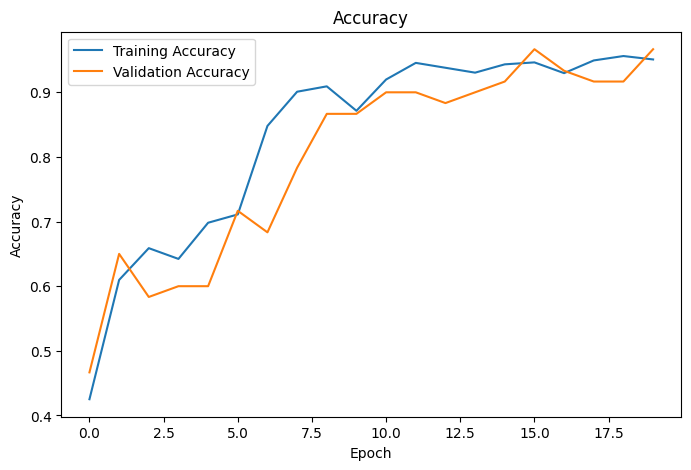

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

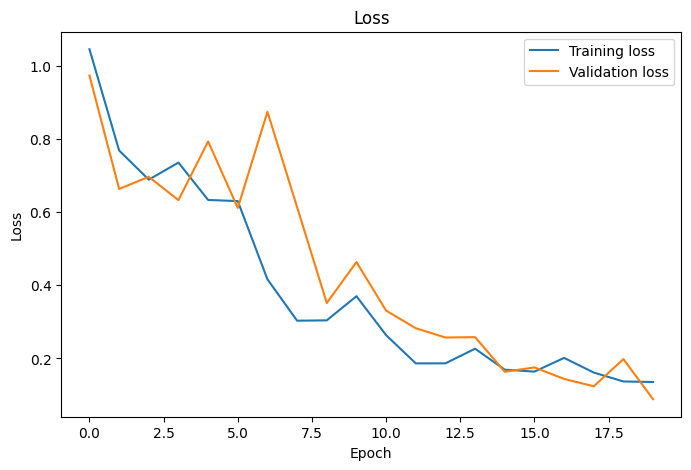

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [15]:
from tensorflow.keras.preprocessing import image
img = image.load_img('Train\Healthy\8bd27e8d6124a5b3.jpg', target_size=(224,224))
img_arr = image.img_to_array(img)

img_arr = np.expand_dims(img_arr, axis=0)
img_arr = img_arr/255.0
predict = model.predict(img_arr)
print(predict)

<>:2: SyntaxWarning: invalid escape sequence '\H'
<>:2: SyntaxWarning: invalid escape sequence '\H'
C:\Users\DELL\AppData\Local\Temp\ipykernel_15516\157469219.py:2: SyntaxWarning: invalid escape sequence '\H'
  img = image.load_img('Train\Healthy\8bd27e8d6124a5b3.jpg', target_size=(224,224))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
[[1. 0. 0.]]


In [16]:
classes = ['Healthy', 'Powdery', 'Rust']
pred = np.argmax(predict, axis=1)[0]
print('Prediction :',classes[pred])

Prediction : Healthy
